<a href="https://colab.research.google.com/github/StaryDron/PigPostureComputerVision/blob/main/PLCM_Pig_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLCM dla klasyfikacji postawy świnek

Adaptacja metody z artykułu *"A Class-Aware Unsupervised Domain Adaptation Framework..."* (Li et al., 2025).

## Mapowanie artykuł → nasz problem

| Artykuł (satelity) | Ten notebook (świnki) |
|---|---|
| Parcela z N pikselami | Świnka z K widokami (augmentacjami per kamera) |
| PSAE (attention pooling po pikselach) | `MultiViewAttentionPooler` (attention po wariantach) |
| Domeny = regiony geograficzne | Domeny = kamery (pen1_orb, pen2_tur, …) |
| Class-aware MMD między domenami | Class-aware MMD między kamerami per klasa |
| Negative transfer: Cotton=0% bez UDA | Negative transfer: Sitting/Standing 14:1 |
| Balanced batch sampler | `WeightedRandomSampler` (jak w artykule) |

### Dwa kluczowe komponenty z artykułu
1. **PSAE** → `MultiViewAttentionPooler`: zamiast średniej/std po pikselach, sieć attention ważąca widoki kamery danej świnki
2. **Class-aware MMD**: zamiast globalnego wyrównania rozkładów, MMD liczone **osobno dla każdej klasy** (eq. 7-8 z artykułu), sterowane pseudo-labelami z progiem τ

In [1]:
# ── Instalacja ─────────────────────────────────────────────────────────────────
!pip install albumentations -q

# ── Kaggle API ────────────────────────────────────────────────────────────────
from google.colab import files
files.upload()

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle competitions download -c multi-view-pig-posture-recognition
!unzip multi-view-pig-posture-recognition.zip
!ls

Streaming output truncated to the last 5000 lines.
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140439.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140759.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140940.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141300.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141439.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141759.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141940.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142300.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142441.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_2

In [2]:
# ── Importy ───────────────────────────────────────────────────────────────────
import os, ast, copy, re, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torchvision.transforms.functional as TF

from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [14]:
# ── Stałe ─────────────────────────────────────────────────────────────────────
CLASS_NAMES = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying",
}
NUM_CLASSES = len(CLASS_NAMES)

BASE_DIR    = Path("multiview_pig_posture_recognition")
TRAIN2_IMGS = BASE_DIR / "train2_images"
TEST_IMGS   = BASE_DIR / "test_images"

BATCH_SIZE  = 32
EPOCHS      = 6        # więcej epok bo mamy 2 etapy treningu
UDA_EPOCHS  = 5         # etap 2: fine-tuning z class-aware MMD
MMD_LAMBDA  = 1.0       # λ z artykułu eq. 9 — balans cls_loss vs mmd_loss
MMD_TAU     = 0.9       # τ z artykułu — próg pewności pseudo-labeli
SAVE_PATH   = "T2_plcm_pig.pt"

print("Stałe ok ✓")

Stałe ok ✓


In [15]:
# ── Parsowanie metadanych kamery ───────────────────────────────────────────────
def parse_camera_meta(image_id):
    m = re.match(r"(pen\d+)_(orb|tur)_(cam\d+)_", image_id)
    if m:
        return m.group(1), m.group(2), m.group(3)
    return "unknown", "unknown", "unknown"

def add_camera_cols(df):
    df["pen"]      = df["image_id"].apply(lambda x: parse_camera_meta(x)[0])
    df["cam_type"] = df["image_id"].apply(lambda x: parse_camera_meta(x)[1])
    df["cam_num"]  = df["image_id"].apply(lambda x: parse_camera_meta(x)[2])
    df["camera"]   = df["pen"] + "_" + df["cam_type"] + "_" + df["cam_num"]
    return df

train2 = pd.read_csv(BASE_DIR / "train2.csv")
train2["source"]      = "train2"
train2["bbox_parsed"] = train2["bbox"].apply(ast.literal_eval)
train2["class_name"]  = train2["class_id"].map(CLASS_NAMES)
train2 = add_camera_cols(train2)

print(f"Train2: {len(train2):,} obs  |  {train2['image_id'].nunique():,} zdjęć")
print("\nRozkład klas:")
print(train2["class_name"].value_counts().to_string())
print("\nRozkład kamer:")
print(train2.groupby("camera")["image_id"].count().sort_values(ascending=False).to_string())

Train2: 23,450 obs  |  3,150 zdjęć

Rozkład klas:
class_name
Standing               9928
Sternal_lying          6309
Lateral_lying_right    3435
Lateral_lying_left     3083
Sitting                 695

Rozkład kamer:
camera
pen2_tur_cam1    9713
pen1_tur_cam2    8194
pen2_orb_cam1    2817
pen1_orb_cam2    1488
pen1_orb_cam1     722
pen1_tur_cam1     200
pen2_tur_cam2     196
pen2_orb_cam2     120


In [16]:
# ── Wczytywanie i przycinanie obrazów ─────────────────────────────────────────
def load_image(image_id, source):
    folder = {"train2": TRAIN2_IMGS, "test": TEST_IMGS}[source]
    return Image.open(folder / image_id).convert("RGB")

def crop_with_padding(image, bbox, padding=0.12, make_square=True):
    """bbox = [x_topleft, y_topleft, w, h]"""
    img_w, img_h = image.size
    x, y, w, h   = map(float, bbox)
    x1 = x - w * padding;      y1 = y - h * padding
    x2 = x + w + w * padding;  y2 = y + h + h * padding
    if make_square:
        side   = max(x2 - x1, y2 - y1)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        x1, x2, y1, y2 = cx - side/2, cx + side/2, cy - side/2, cy + side/2
    x1 = max(0, int(round(x1)));      y1 = max(0, int(round(y1)))
    x2 = min(img_w, int(round(x2)));  y2 = min(img_h, int(round(y2)))
    return image.crop((max(x1, 0), max(y1, 0), max(x2, x1+1), max(y2, y1+1)))

In [17]:
# ── Augmentacje per kamera (PRZEPISANE pod strategię SOURCE=duże, TARGET=małe) ─
#
# STRATEGIA (potwierdzona przez nas):
#   SOURCE (duże, dużo danych, ground truth):
#     pen2_tur_cam1 (19,426), pen1_tur_cam2 (16,388)
#   TARGET (małe, mało danych, domain shift, dostają pseudo-labele):
#     pen2_orb_cam1 (5,634), pen1_orb_cam2 (2,976), pen1_orb_cam1 (1,444),
#     pen1_tur_cam1 (200),   pen2_tur_cam2 (196),   pen2_orb_cam2 (120)
#
# Test = mix różnych kamer → musimy nauczyć cech inwariantnych na domeny.
#
# ZASADA AUGMENTACJI:
#   - SOURCE: lekkie augmentacje (flip + delikatne zmiany koloru) — bo
#     mamy DUŻO próbek, nie chcemy ich przekrzywiać sztucznym domain shiftem.
#     Flip horyzontalny zwiększa różnorodność i jest legalny (klasy L/R się zamieniają).
#   - TARGET: mocniejsze augmentacje (mocniejsza zmiana koloru/kontrastu/grayscale),
#     żeby SYMULOWAĆ pełną gamę domen, których model nie widzi w treningu.
#     Tu chcemy żeby model NIE PRZYZWYCZAIŁ się do kolorystyki konkretnej kamery —
#     bo augmentowany TARGET reprezentuje "domain wszechświat" do którego dopasowujemy
#     SOURCE przez MMD.

FLIP_LABEL_MAP = {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}

# ── SOURCE: aug = flip + bardzo lekka regularyzacja koloru ────────────────────
def aug_pen2_tur_cam1(img):
    """SOURCE (19,426 obs). Flip horyzontalny + bardzo lekka regularyzacja."""
    img = TF.hflip(img)
    img = TF.adjust_saturation(img, saturation_factor=0.9)
    img = TF.adjust_brightness(img, brightness_factor=0.97)
    return img

def aug_pen1_tur_cam2(img):
    """SOURCE (16,388 obs). Flip horyzontalny + bardzo lekka regularyzacja."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=1.05)
    img = TF.adjust_saturation(img, saturation_factor=0.95)
    return img

# ── TARGET: aug = mocniejsze, symulujące pełen domain shift ───────────────────
def aug_pen2_orb_cam1(img):
    """TARGET (5,634 obs). Flip + przyciemnienie + kontrast + zielonkawy shift + greyscale."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=0.6)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_np = np.array(img).astype(float)
    img_np[:, :, 0] = (img_np[:, :, 0] * 0.85).clip(0, 255)
    img_np[:, :, 1] = (img_np[:, :, 1] * 1.10).clip(0, 255)
    img_np[:, :, 2] = (img_np[:, :, 2] * 0.80).clip(0, 255)
    img_shifted = Image.fromarray(img_np.clip(0, 255).astype(np.uint8))
    img_grey    = TF.to_grayscale(img_shifted, num_output_channels=3)
    grey_np     = np.array(img_grey).astype(float)
    blended     = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

def aug_pen1_orb_cam2(img):
    """TARGET (2,976 obs). Flip + przyciemnienie + lekki greyscale."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=0.75)
    img = TF.adjust_contrast(img, contrast_factor=1.3)
    img_grey = TF.to_grayscale(img, num_output_channels=3)
    img_np   = np.array(img).astype(float)
    grey_np  = np.array(img_grey).astype(float)
    blended  = (0.75 * img_np + 0.25 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

def aug_pen1_orb_cam1(img):
    """TARGET (1,444 obs). Lekkie przyciemnienie + greyscale (bez flipa — mała kamera referencyjna)."""
    img = TF.adjust_brightness(img, brightness_factor=0.8)
    img = TF.adjust_contrast(img, contrast_factor=1.2)
    img_grey = TF.to_grayscale(img, num_output_channels=3)
    img_np   = np.array(img).astype(float)
    grey_np  = np.array(img_grey).astype(float)
    blended  = (0.8 * img_np + 0.2 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

def aug_pen1_tur_cam1(img):
    """TARGET (200 obs). Flip + rozjaśnienie + desaturacja — mocno aug bo MAŁO danych."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=1.3)
    img = TF.adjust_saturation(img, saturation_factor=0.85)
    img = TF.adjust_contrast(img, contrast_factor=1.15)
    return img

def aug_pen2_tur_cam2(img):
    """TARGET (196 obs). Rozjaśnienie + desaturacja — mocno aug bo MAŁO danych."""
    img = TF.adjust_brightness(img, brightness_factor=1.3)
    img = TF.adjust_saturation(img, saturation_factor=0.85)
    img = TF.adjust_contrast(img, contrast_factor=1.15)
    return img

def aug_pen2_orb_cam2(img):
    """TARGET (120 obs). Przyciemnienie + kontrast + greyscale — bardzo mała kamera."""
    img = TF.adjust_brightness(img, brightness_factor=0.60)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_grey = TF.to_grayscale(img, num_output_channels=3)
    img_np   = np.array(img).astype(float)
    grey_np  = np.array(img_grey).astype(float)
    blended  = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

# Wszystkie 8 kamer mają aug — ale rola (source/target) jest niezależna od aug.
# (flip_label) = True tylko gdy aug zawiera hflip i klasy lewo/prawo się zamieniają.
CAMERA_AUG_FN = {
    # SOURCE
    "pen2_tur_cam1": (aug_pen2_tur_cam1, True),
    "pen1_tur_cam2": (aug_pen1_tur_cam2, True),
    # TARGET
    "pen2_orb_cam1": (aug_pen2_orb_cam1, True),
    "pen1_orb_cam2": (aug_pen1_orb_cam2, True),
    "pen1_orb_cam1": (aug_pen1_orb_cam1, False),
    "pen1_tur_cam1": (aug_pen1_tur_cam1, True),
    "pen2_tur_cam2": (aug_pen2_tur_cam2, False),
    "pen2_orb_cam2": (aug_pen2_orb_cam2, False),
}

# Jawnie definiujemy role kamer — używane potem w etapie 2 UDA
SOURCE_CAMERAS = {"pen2_tur_cam1", "pen1_tur_cam2"}
TARGET_CAMERAS = {"pen2_orb_cam1", "pen1_orb_cam2", "pen1_orb_cam1",
                  "pen1_tur_cam1", "pen2_tur_cam2", "pen2_orb_cam2"}

# Sanity check: każda kamera ma rolę i każda ma aug
all_cams_in_data = set(train2["camera"].unique())
assert (SOURCE_CAMERAS | TARGET_CAMERAS) >= all_cams_in_data, \
    f"Brak roli dla kamer: {all_cams_in_data - SOURCE_CAMERAS - TARGET_CAMERAS}"
assert SOURCE_CAMERAS.isdisjoint(TARGET_CAMERAS), "Kamera nie może być i source i target"

print("Augmentacje per kamera zdefiniowane ✓")
print(f"\nSOURCE ({len(SOURCE_CAMERAS)} kamer, duża ilość danych):")
for cam in sorted(SOURCE_CAMERAS):
    n = (train2["camera"] == cam).sum()
    flip = CAMERA_AUG_FN[cam][1]
    print(f"  {cam:20s} obs={n:>6,}  flip_label={flip}")
print(f"\nTARGET ({len(TARGET_CAMERAS)} kamer, mała ilość danych, domain shift):")
for cam in sorted(TARGET_CAMERAS, key=lambda c: -(train2["camera"] == c).sum()):
    n = (train2["camera"] == cam).sum()
    flip = CAMERA_AUG_FN[cam][1]
    print(f"  {cam:20s} obs={n:>6,}  flip_label={flip}")


Augmentacje per kamera zdefiniowane ✓

SOURCE (2 kamer, duża ilość danych):
  pen1_tur_cam2        obs= 8,194  flip_label=True
  pen2_tur_cam1        obs= 9,713  flip_label=True

TARGET (6 kamer, mała ilość danych, domain shift):
  pen2_orb_cam1        obs= 2,817  flip_label=True
  pen1_orb_cam2        obs= 1,488  flip_label=True
  pen1_orb_cam1        obs=   722  flip_label=False
  pen1_tur_cam1        obs=   200  flip_label=True
  pen2_tur_cam2        obs=   196  flip_label=False
  pen2_orb_cam2        obs=   120  flip_label=False


In [18]:
# ── Transformy ────────────────────────────────────────────────────────────────
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.15):
        self.std, self.p = std, p
    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            tensor = torch.clamp(
                tensor + torch.randn_like(tensor) * self.std, 0., 1.)
        return tensor

BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.15),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [19]:
# ── Dataset z augmentacjami per kamera (jak poprzednio) ───────────────────────
class PigDatasetCameraAug(Dataset):
    """
    Identyczny jak poprzednio — zachowujemy augmentacje per kamera.
    Dla każdej obserwacji: oryginał + (opcjonalnie) wersja zaugmentowana.
    """
    def __init__(self, df, camera_aug_fn, base_transform, is_train=True):
        self.base_transform  = base_transform
        self.camera_aug_fn   = camera_aug_fn
        self.is_train        = is_train
        self.samples = []
        df = df.reset_index(drop=True)
        self.df = df

        for idx, row in df.iterrows():
            cam   = row.get("camera", "unknown")
            label = int(row["class_id"])
            self.samples.append((idx, False, label, cam))
            if is_train and cam in camera_aug_fn:
                _, flip_label = camera_aug_fn[cam]
                new_label = FLIP_LABEL_MAP[label] if flip_label else label
                self.samples.append((idx, True, new_label, cam))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row_idx, do_aug, label, cam = self.samples[idx]
        row   = self.df.iloc[row_idx]
        image = load_image(row["image_id"], row["source"])
        crop  = crop_with_padding(image, row["bbox_parsed"],
                                  padding=0.12, make_square=True)
        if do_aug:
            aug_fn, _ = self.camera_aug_fn[cam]
            crop = aug_fn(crop)
        crop = self.base_transform(crop)
        return crop, label, cam

train_dataset = PigDatasetCameraAug(
    train2, CAMERA_AUG_FN, BASE_TRANSFORM, is_train=True
)

print(f"Obserwacji w train2:        {len(train2):,}")
print(f"Obserwacji po augmentacji:  {len(train_dataset):,}")

all_labels   = [s[2] for s in train_dataset.samples]
label_counts = Counter(all_labels)
print("\nRozkład labeli po augmentacji:")
for cid, cnt in sorted(label_counts.items()):
    print(f"  {CLASS_NAMES[cid]:25s}: {cnt}")

Obserwacji w train2:        23,450
Obserwacji po augmentacji:  46,900

Rozkład labeli po augmentacji:
  Lateral_lying_left       : 6492
  Lateral_lying_right      : 6544
  Sitting                  : 1390
  Standing                 : 19856
  Sternal_lying            : 12618


In [20]:
# ── Balanced sampler (= balanced batch sampler z artykułu, sekcja 3.4.2) ──────
#
# Artykuł: "we employed a class-balanced batch sampler to ensure that the
# number of samples for each class was approximately equal in every training batch"
# → odpowiednik WeightedRandomSampler z wagami 1/class_count

class_counts   = np.bincount(all_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / np.maximum(class_counts, 1)
sample_weights = np.array([class_weights[l] for l in all_labels])

print("Liczebność klas po augmentacji:", class_counts)
print("Wagi klas (1/count):           ", np.round(class_weights, 5))

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)} ✓")

Liczebność klas po augmentacji: [ 6492  6544  1390 19856 12618]
Wagi klas (1/count):            [1.5e-04 1.5e-04 7.2e-04 5.0e-05 8.0e-05]
Train batches: 1466 ✓


In [21]:
# ── PSAE — Pixel-Set Attention Encoder zaadaptowany do świnek ─────────────────
#
# Artykuł sekcja 3.2.1:
# Oryginalne PSAE agreguje N pikselów parceli → 1 wektor per timestep
# za pomocą attention poolingu (zamiast prostej średniej/std jak w PSE).
#
# Tutaj: agregujemy K "widoków" tej samej świnki (oryginał + aug kamery)
# za pomocą attention → 1 wektor reprezentujący świnkę.
# K=1 gdy kamera nie ma aug, K=2 gdy ma.
#
# Wzory z artykułu (eq. 1-3):
#   ê_S = MLP1(x_S)                        ← projekcja każdego widoku
#   p   = AttentionPooling(ê_S)            ← attention po widokach
#   e   = MLP2(p)                          ← finalna reprezentacja

class MultiViewAttentionPooler(nn.Module):
    """
    Odpowiednik PSAE z artykułu.
    Wejście: tensor [B, K, feat_dim] — B próbek, K widoków, feat_dim cech
    Wyjście: tensor [B, feat_dim]    — zagregowany wektor per próbka

    Gdy K=1 (kamera bez aug), self-attention degeneruje się do identity.
    Gdy K=2 (oryginał + aug), attention uczy się ważyć oba widoki.
    """
    def __init__(self, feat_dim: int, hidden_dim: int = 256):
        super().__init__()
        # MLP1 — odpowiednik weight-sharing MLP1 z PSAE
        self.mlp1 = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        # Attention pooling — Q, K liniowe (jak w PSAE Figure 10)
        self.attn_q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.attn_k = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.scale  = hidden_dim ** -0.5
        # MLP2 — finalna transformacja po poolingu
        self.mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, feat_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, K, feat_dim]
        e_hat = self.mlp1(x)                               # [B, K, hidden_dim]
        Q = self.attn_q(e_hat)                             # [B, K, H]
        K_ = self.attn_k(e_hat)                            # [B, K, H]
        # Attention weights: globalna query (mean) × keys
        q_global = Q.mean(dim=1, keepdim=True)             # [B, 1, H]
        scores   = (q_global * K_).sum(dim=-1) * self.scale  # [B, K]
        weights  = torch.softmax(scores, dim=-1)           # [B, K]
        # Weighted sum po widokach (jak AttentionPooling w artykule)
        p = (weights.unsqueeze(-1) * e_hat).sum(dim=1)     # [B, hidden_dim]
        e = self.mlp2(p)                                   # [B, feat_dim]
        return e


print("MultiViewAttentionPooler (≡ PSAE) zdefiniowany ✓")

MultiViewAttentionPooler (≡ PSAE) zdefiniowany ✓


In [22]:
# ── Class-Aware MMD (eq. 7-9 z artykułu) ─────────────────────────────────────
#
# Artykuł sekcja 3.3:
# Zamiast globalnego wyrównania rozkładów (standard MMD),
# liczymy MMD osobno dla każdej klasy c ∈ {0,...,C}.
#
# Dla klasy c:
#   F_s^c = cechy z kamery referencyjnej (source), gdzie label = c
#   F_t^c = cechy z innych kamer (target), gdzie pseudo-label = c
#            i max(p_j) > τ (tylko wysokiej pewności)
#
# L_mmd = (1/C') * Σ_c MMD²(F_s^c, F_t^c)  [eq. 8]
#
# Gaussian kernel: k(x,y) = exp(-||x-y||² / (2σ²))
# Wielokrotne σ (multi-scale) jak w standardowym MMD z RKHS

def gaussian_kernel_matrix(x: torch.Tensor, y: torch.Tensor,
                            sigmas=(0.1, 0.5, 1.0, 2.0, 5.0)) -> torch.Tensor:
    """Suma jąder Gaussowskich dla różnych σ — multi-scale RBF kernel."""
    dist = torch.cdist(x, y, p=2) ** 2   # [N, M]
    result = torch.zeros_like(dist)
    for sigma in sigmas:
        result += torch.exp(-dist / (2.0 * sigma ** 2))
    return result / len(sigmas)


def mmd_squared(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """MMD² między dwoma zbiorami cech (eq. 7 z artykułu)."""
    Kxx = gaussian_kernel_matrix(x, x)
    Kyy = gaussian_kernel_matrix(y, y)
    Kxy = gaussian_kernel_matrix(x, y)
    return Kxx.mean() - 2 * Kxy.mean() + Kyy.mean()


def class_aware_mmd_loss(
    source_feats:  torch.Tensor,   # [N_s, D] cechy z kamery referencyjnej
    source_labels: torch.Tensor,   # [N_s]    prawdziwe etykiety
    target_feats:  torch.Tensor,   # [N_t, D] cechy z innych kamer
    target_probs:  torch.Tensor,   # [N_t, C] prawdopodobieństwa (softmax)
    tau:           float = 0.9,
    num_classes:   int   = 5,
) -> torch.Tensor:
    """
    Class-Aware MMD Loss — eq. 7-8 z artykułu.

    Kluczowa różnica vs standard MMD:
    - Standard MMD: jeden duży MMD na wszystkich cechach
      → ryzyko negative transfer (np. Sitting/Standing blurring)
    - Class-aware MMD: osobny MMD per klasa, tylko high-confidence samples
      → każda klasa wyrównywana niezależnie, bez mieszania granic klas
    """
    # Pseudo-labele z progiem τ (jak w artykule)
    max_probs, pseudo_labels = target_probs.max(dim=1)  # [N_t]
    high_conf_mask = max_probs > tau                     # [N_t]

    total_mmd   = torch.tensor(0.0, device=source_feats.device)
    valid_classes = 0

    for c in range(num_classes):
        # F_s^c — cechy source dla klasy c (ground truth)
        src_mask = (source_labels == c)
        if src_mask.sum() < 2:
            continue
        F_s_c = source_feats[src_mask]   # [N_s_c, D]

        # F_t^c — cechy target z wysoką pewnością pseudo-labela c (eq. 8)
        tgt_mask = high_conf_mask & (pseudo_labels == c)
        if tgt_mask.sum() < 2:
            continue
        F_t_c = target_feats[tgt_mask]   # [N_t_c, D]

        total_mmd   += mmd_squared(F_s_c, F_t_c)
        valid_classes += 1

    if valid_classes == 0:
        return torch.tensor(0.0, device=source_feats.device, requires_grad=True)

    return total_mmd / valid_classes   # średnia po klasach (eq. 8)


print("Class-Aware MMD zdefiniowane ✓")
print(f"  τ (próg pseudo-labeli) = {MMD_TAU}")
print(f"  λ (waga L_mmd w L_total) = {MMD_LAMBDA}")

Class-Aware MMD zdefiniowane ✓
  τ (próg pseudo-labeli) = 0.9
  λ (waga L_mmd w L_total) = 1.0


In [23]:
# ── Model PLCM: EfficientNetV2-S + MultiViewAttentionPooler ───────────────────
#
# Architektura (analogia do PSAE-LTAE z artykułu):
#   EfficientNetV2-S (backbone) = ekstraktor cech z pojedynczego widoku
#   MultiViewAttentionPooler    = PSAE (agregacja wielu widoków)
#   Linear classifier           = decoder (MLP z artykułu)
#
# LTAE z artykułu (temporal attention) nie ma bezpośredniego odpowiednika
# bo świnki nie mają szeregów czasowych — PSAE wystarczy.

class PLCMPigClassifier(nn.Module):
    def __init__(self, num_classes: int = 5, feat_dim: int = 1280):
        super().__init__()
        # Backbone — EfficientNetV2-S (jak w oryginalnym notebooku)
        backbone = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )
        # Usuwamy głowicę klasyfikacyjną — chcemy cechy
        self.feature_extractor = backbone.features
        self.avgpool           = backbone.avgpool
        self.feat_dim          = feat_dim

        # MultiViewAttentionPooler (≡ PSAE)
        self.pooler = MultiViewAttentionPooler(feat_dim=feat_dim, hidden_dim=512)

        # Klasyfikator (≡ MLP decoder z artykułu)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, num_classes)
        )

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Wyciąga cechy z pojedynczego obrazu: [B, feat_dim]"""
        feats = self.feature_extractor(x)     # [B, C, H, W]
        feats = self.avgpool(feats)            # [B, C, 1, 1]
        return feats.flatten(1)               # [B, feat_dim]

    def forward_single(self, x: torch.Tensor):
        """
        Standardowy forward dla pojedynczego widoku (K=1).
        Używany przy testowaniu i w etapie 1.
        Zwraca: logits [B, C], features [B, D]
        """
        feats  = self.extract_features(x)     # [B, D]
        # Pooler z K=1 (attention po jednym widoku = identity)
        pooled = self.pooler(feats.unsqueeze(1)).squeeze(1)  # [B, D]
        logits = self.classifier(pooled)      # [B, C]
        return logits, pooled

    def forward_multiview(self, views: list):
        """
        Forward dla wielu widoków tej samej świnki (K>1).
        views: lista tensorów [B, 3, 224, 224], każdy to inny widok
        Zwraca: logits [B, C], aggregated_features [B, D]
        """
        all_feats = [self.extract_features(v) for v in views]  # K × [B, D]
        stacked   = torch.stack(all_feats, dim=1)               # [B, K, D]
        pooled    = self.pooler(stacked)                        # [B, D]
        logits    = self.classifier(pooled)                     # [B, C]
        return logits, pooled

    def forward(self, x: torch.Tensor):
        """Default forward = single view (kompatybilność z etapem 1)."""
        return self.forward_single(x)


model = PLCMPigClassifier(num_classes=NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"PLCMPigClassifier | parametry: {n_params:,}")
print(f"  EfficientNetV2-S backbone + MultiViewAttentionPooler (PSAE) ✓")

PLCMPigClassifier | parametry: 22,283,349
  EfficientNetV2-S backbone + MultiViewAttentionPooler (PSAE) ✓


In [24]:
# ── Etap 1: Supervised Pre-training (jak w artykule sekcja 3.1 punkt 1) ───────
#
# "In this initial stage, the core PSAE-LTAE model is trained exclusively
#  on the labeled source dataset D_S using a standard supervised learning approach."
#
# Tu: trenujemy na wszystkich danych (kamery = mixed domains, bo nie wiemy
# która jest referencyjna bez walidacji). Uczymy dobrej reprezentacji.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)


def train_supervised_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    n_batches = len(loader)

    for batch_i, (images, labels, _cams) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        filled = int(30 * (batch_i + 1) / n_batches)
        bar    = "█" * filled + "░" * (30 - filled)
        print(f"\r  [train] |{bar}| {100*(batch_i+1)/n_batches:5.1f}%"
              f"  loss={loss.item():.4f}", end="", flush=True)

    print()
    n = len(loader.dataset)
    return (total_loss / n,
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro"))


best_f1, best_state, history = 0.0, None, []

print("=" * 60)
print("ETAP 1 — Supervised Pre-training")
print("=" * 60)

for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = train_supervised_epoch(
        model, train_loader, optimizer, criterion
    )
    elapsed = time.time() - t0
    scheduler.step(tr_f1)

    history.append({"epoch": epoch+1, "stage": "supervised",
                    "train_loss": tr_loss, "train_acc": tr_acc, "train_f1": tr_f1})

    flag = "  ← best" if tr_f1 > best_f1 else ""
    print(f"Epoch {epoch+1:>2}/{EPOCHS} ({elapsed/60:.1f} min) | "
          f"loss {tr_loss:.4f}  acc {tr_acc:.4f}  f1 {tr_f1:.4f}"
          f"  lr {optimizer.param_groups[0]['lr']:.1e}{flag}")

    if tr_f1 > best_f1:
        best_f1    = tr_f1
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"model_state_dict": best_state,
                    "class_names": CLASS_NAMES,
                    "best_train_f1": best_f1,
                    "epoch": epoch + 1, "stage": "supervised"}, SAVE_PATH)
        print(f"  💾 Zapisano → {SAVE_PATH}")

print(f"\nNajlepsze train macro-F1 (etap 1): {best_f1:.4f}")

ETAP 1 — Supervised Pre-training
  [train] |██████████████████████████████| 100.0%  loss=0.2188
Epoch  1/6 (13.4 min) | loss 0.3886  acc 0.8489  f1 0.8486  lr 1.0e-04  ← best
  💾 Zapisano → T2_plcm_pig.pt
  [train] |██████████████████████████████| 100.0%  loss=0.0234
Epoch  2/6 (13.2 min) | loss 0.1106  acc 0.9649  f1 0.9648  lr 1.0e-04  ← best
  💾 Zapisano → T2_plcm_pig.pt
  [train] |██████████████████████████████| 100.0%  loss=0.0674
Epoch  3/6 (13.2 min) | loss 0.0806  acc 0.9755  f1 0.9754  lr 1.0e-04  ← best
  💾 Zapisano → T2_plcm_pig.pt
  [train] |██████████████████████████████| 100.0%  loss=0.0292
Epoch  4/6 (13.3 min) | loss 0.0608  acc 0.9814  f1 0.9814  lr 1.0e-04  ← best
  💾 Zapisano → T2_plcm_pig.pt
  [train] |██████████████████████████████| 100.0%  loss=0.0077
Epoch  5/6 (13.2 min) | loss 0.0520  acc 0.9847  f1 0.9847  lr 1.0e-04  ← best
  💾 Zapisano → T2_plcm_pig.pt
  [train] |██████████████████████████████| 100.0%  loss=0.0340
Epoch  6/6 (13.6 min) | loss 0.0458  acc 0.9

In [28]:
# ── Pobranie checkpointu etapu 1 na lokalny laptop ────────────────────────
from google.colab import files
import os

print(f"Rozmiar pliku: {os.path.getsize(SAVE_PATH) / 1e6:.1f} MB")
print(f"best_f1 = {best_f1:.4f}")

files.download(SAVE_PATH)

Rozmiar pliku: 90.1 MB
best_f1 = 0.9861


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ── Etap 2: UDA Fine-tuning z Class-Aware MMD ─────────────────────────────────
#
# Artykuł sekcja 3.1 punkt 2 + sekcja 3.3:
# "Using the pre-trained weights as a starting point, the model is then
#  fine-tuned with both the source domain D_S and the unlabeled target domain D_T."
#
# Adaptacja do świnek (NOWA STRATEGIA):
#   SOURCE domain = DUŻE kamery (pen2_tur_cam1 + pen1_tur_cam2)
#     ~36k obserwacji, świetny ground truth — używamy LABELI w L_cls
#   TARGET domain = MAŁE kamery (pozostałe 6)
#     ~12k obserwacji, słabiej reprezentowane → traktujemy jako "unlabeled"
#     (chociaż mamy label, w UDA udajemy że nie mamy — używamy pseudo-labeli)
#
# Test = mix kamer → wyrównanie source↔target rozkładów cech pomaga generalizować.
#
# L_total = L_cls(X_s, Y_s) + λ * L_mmd(F_s, F_t, Y_s, Ŷ_t)  [eq. 9]

# Wczytujemy najlepsze wagi z etapu 1 (jak w artykule)
model.load_state_dict(best_state)
print(f"Wagi z etapu 1 wczytane (F1={best_f1:.4f}) ✓")

# SOURCE_CAMERAS i TARGET_CAMERAS są zdefiniowane w komórce z augmentacjami
print(f"Source kamery (duże, ground truth): {sorted(SOURCE_CAMERAS)}")
print(f"Target kamery (małe, pseudo-label): {sorted(TARGET_CAMERAS)}")

# Obniżamy LR do fine-tuningu (jak zalecone w artykule)
optimizer_uda = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

# Budujemy wektory przynależności do source/target dla każdej próbki
source_mask = np.array([cam in SOURCE_CAMERAS for _, _, _, cam in train_dataset.samples])
target_mask = np.array([cam in TARGET_CAMERAS for _, _, _, cam in train_dataset.samples])

# Sanity: każda próbka musi być source ALBO target, nie obie i nie żadna
assert (source_mask | target_mask).all(), "Są próbki bez przypisanej roli!"
assert not (source_mask & target_mask).any(), "Są próbki przypisane do obu ról!"

print(f"\nPróbki source: {source_mask.sum():,}")
print(f"Próbki target: {target_mask.sum():,}")
print(f"Stosunek source/target: {source_mask.sum()/max(target_mask.sum(),1):.2f}x")


Wagi z etapu 1 wczytane (F1=0.9861) ✓
Source kamery (duże, ground truth): ['pen1_tur_cam2', 'pen2_tur_cam1']
Target kamery (małe, pseudo-label): ['pen1_orb_cam1', 'pen1_orb_cam2', 'pen1_tur_cam1', 'pen2_orb_cam1', 'pen2_orb_cam2', 'pen2_tur_cam2']

Próbki source: 35,814
Próbki target: 11,086
Stosunek source/target: 3.23x


In [26]:
# ── Dataloader dla UDA (osobne loadery source i target) ───────────────────────
#
# Artykuł sekcja 3.4.2:
# "In each iteration, we simultaneously sampled one batch of data from the source
#  domain (using a balanced sampler) and one from the target domain"

from torch.utils.data import Subset

source_indices = np.where(source_mask)[0]
target_indices = np.where(target_mask)[0]

source_dataset = Subset(train_dataset, source_indices)
target_dataset = Subset(train_dataset, target_indices)

# Balanced sampler tylko dla source (jak w artykule — source ma ground truth)
src_labels    = [train_dataset.samples[i][2] for i in source_indices]
src_counts    = np.bincount(src_labels, minlength=NUM_CLASSES)
src_weights   = 1.0 / np.maximum(src_counts, 1)
src_sw        = np.array([src_weights[l] for l in src_labels])

source_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(src_sw),
    num_samples=len(src_sw),
    replacement=True
)

source_loader = DataLoader(source_dataset, batch_size=BATCH_SIZE,
                            sampler=source_sampler, num_workers=2, pin_memory=True)
target_loader = DataLoader(target_dataset, batch_size=BATCH_SIZE,
                            shuffle=True, num_workers=2, pin_memory=True,
                            drop_last=True)

print(f"Source loader: {len(source_loader)} batchy  ({len(source_dataset):,} próbek)")
print(f"Target loader: {len(target_loader)} batchy  ({len(target_dataset):,} próbek)")

Source loader: 1120 batchy  (35,814 próbek)
Target loader: 346 batchy  (11,086 próbek)


In [29]:
# ── Pętla UDA fine-tuningu ────────────────────────────────────────────────────

def train_uda_epoch(model, src_loader, tgt_loader, optimizer, criterion,
                    mmd_lambda=1.0, tau=0.9, n_iters=200):
    """
    Jeden epoch UDA (eq. 9 z artykułu):
    L_total = L_cls(X_s, Y_s) + λ * L_mmd(F_s, F_t, Y_s, Ŷ_t)

    n_iters = 200 iteracji na epokę (jak w artykule sekcja 3.4.2)
    """
    model.train()
    total_cls_loss = 0.0
    total_mmd_loss = 0.0
    all_preds, all_labels_list = [], []

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_loader)

    for i in range(n_iters):
        # Pobieramy batch source (z ground truth labels)
        try:
            src_imgs, src_labels, _ = next(src_iter)
        except StopIteration:
            src_iter = iter(src_loader)
            src_imgs, src_labels, _ = next(src_iter)

        # Pobieramy batch target (bez labels — UDA)
        try:
            tgt_imgs, _tgt_labels_unused, _ = next(tgt_iter)
        except StopIteration:
            tgt_iter = iter(tgt_loader)
            tgt_imgs, _tgt_labels_unused, _ = next(tgt_iter)

        src_imgs   = src_imgs.to(DEVICE)
        src_labels = src_labels.to(DEVICE)
        tgt_imgs   = tgt_imgs.to(DEVICE)

        optimizer.zero_grad()

        # Forward source — klasyfikacja (L_cls)
        src_logits, src_feats = model(src_imgs)
        cls_loss = criterion(src_logits, src_labels)

        # Forward target — tylko ekstrakcja cech + pseudo-labels
        with torch.no_grad():
            # Pseudo-labels z modelu (bez gradientu, jak w artykule)
            tgt_logits_no_grad, _ = model(tgt_imgs)
            tgt_probs = F.softmax(tgt_logits_no_grad, dim=1)  # [B, C]

        # Liczymy target features z gradientem (potrzebne do MMD backprop)
        _, tgt_feats = model(tgt_imgs)

        # Class-Aware MMD (L_mmd) — eq. 7-8 z artykułu
        mmd_loss = class_aware_mmd_loss(
            source_feats  = src_feats,
            source_labels = src_labels,
            target_feats  = tgt_feats,
            target_probs  = tgt_probs,
            tau           = tau,
            num_classes   = NUM_CLASSES,
        )

        # L_total = L_cls + λ * L_mmd  [eq. 9]
        total_loss = cls_loss + mmd_lambda * mmd_loss
        total_loss.backward()
        optimizer.step()

        total_cls_loss += cls_loss.item()
        total_mmd_loss += mmd_loss.item()
        all_preds.extend(src_logits.argmax(1).detach().cpu().numpy())
        all_labels_list.extend(src_labels.cpu().numpy())

        if (i + 1) % 50 == 0:
            print(f"  iter {i+1:>3}/{n_iters}  "
                  f"cls={cls_loss.item():.4f}  mmd={mmd_loss.item():.4f}",
                  flush=True)

    cls_avg = total_cls_loss / n_iters
    mmd_avg = total_mmd_loss / n_iters
    tr_f1   = f1_score(all_labels_list, all_preds, average="macro")
    return cls_avg, mmd_avg, tr_f1


uda_best_f1    = best_f1
uda_best_state = copy.deepcopy(model.state_dict())

print("=" * 60)
print("ETAP 2 — UDA Fine-tuning (Class-Aware MMD)")
print(f"  λ={MMD_LAMBDA}, τ={MMD_TAU}")
print("=" * 60)

for epoch in range(UDA_EPOCHS):
    t0 = time.time()
    cls_loss, mmd_loss, tr_f1 = train_uda_epoch(
        model, source_loader, target_loader,
        optimizer_uda, criterion,
        mmd_lambda=MMD_LAMBDA, tau=MMD_TAU, n_iters=200
    )
    elapsed = time.time() - t0

    history.append({"epoch": EPOCHS + epoch + 1, "stage": "uda",
                    "train_loss": cls_loss, "mmd_loss": mmd_loss,
                    "train_acc": 0.0, "train_f1": tr_f1})

    flag = "  ← best" if tr_f1 > uda_best_f1 else ""
    print(f"UDA Epoch {epoch+1:>2}/{UDA_EPOCHS} ({elapsed/60:.1f} min) | "
          f"cls {cls_loss:.4f}  mmd {mmd_loss:.4f}  src_f1 {tr_f1:.4f}"
          f"  lr {optimizer_uda.param_groups[0]['lr']:.1e}{flag}")

    if tr_f1 > uda_best_f1:
        uda_best_f1    = tr_f1
        uda_best_state = copy.deepcopy(model.state_dict())
        torch.save({"model_state_dict": uda_best_state,
                    "class_names": CLASS_NAMES,
                    "best_train_f1": uda_best_f1,
                    "epoch": EPOCHS + epoch + 1, "stage": "uda"}, SAVE_PATH)
        print(f"  💾 Zapisano → {SAVE_PATH}")

print(f"\nNajlepsze macro-F1 po UDA fine-tuningu: {uda_best_f1:.4f}")

ETAP 2 — UDA Fine-tuning (Class-Aware MMD)
  λ=1.0, τ=0.9
  iter  50/200  cls=0.0054  mmd=0.5076
  iter 100/200  cls=0.0084  mmd=0.2929
  iter 150/200  cls=0.0102  mmd=0.3694
  iter 200/200  cls=0.0073  mmd=0.3712
UDA Epoch  1/5 (4.6 min) | cls 0.0307  mmd 0.3519  src_f1 0.9902  lr 1.0e-05  ← best
  💾 Zapisano → T2_plcm_pig.pt
  iter  50/200  cls=0.0027  mmd=0.2757
  iter 100/200  cls=0.0241  mmd=0.2718
  iter 150/200  cls=0.0102  mmd=0.2254
  iter 200/200  cls=0.0124  mmd=0.3262
UDA Epoch  2/5 (4.6 min) | cls 0.0263  mmd 0.3396  src_f1 0.9915  lr 1.0e-05  ← best
  💾 Zapisano → T2_plcm_pig.pt
  iter  50/200  cls=0.0173  mmd=0.3105
  iter 100/200  cls=0.0030  mmd=0.3651
  iter 150/200  cls=0.0047  mmd=0.2847
  iter 200/200  cls=0.0144  mmd=0.3327
UDA Epoch  3/5 (4.6 min) | cls 0.0254  mmd 0.3310  src_f1 0.9923  lr 1.0e-05  ← best
  💾 Zapisano → T2_plcm_pig.pt
  iter  50/200  cls=0.0243  mmd=0.3001
  iter 100/200  cls=0.0027  mmd=0.2855
  iter 150/200  cls=0.0123  mmd=0.3027
  iter 200/2

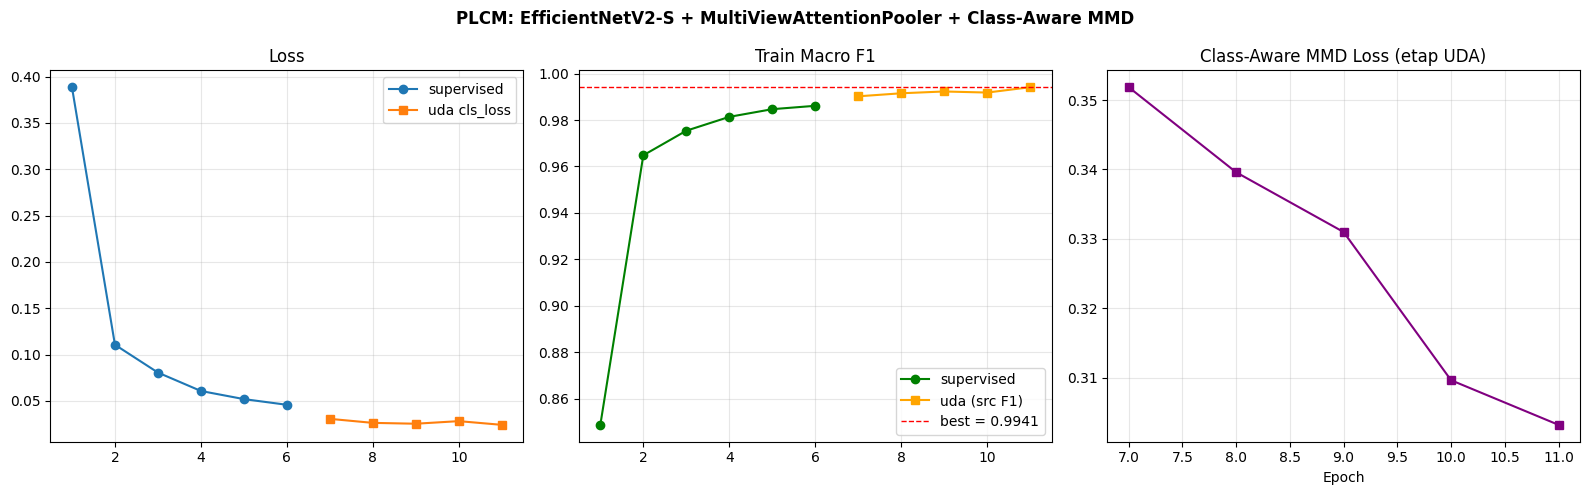

In [30]:
# ── Wykres treningu ───────────────────────────────────────────────────────────
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sup_df = hist_df[hist_df["stage"] == "supervised"]
uda_df = hist_df[hist_df["stage"] == "uda"]

axes[0].plot(sup_df["epoch"], sup_df["train_loss"], marker="o", label="supervised")
axes[0].plot(uda_df["epoch"], uda_df["train_loss"], marker="s", label="uda cls_loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sup_df["epoch"], sup_df["train_f1"], marker="o", color="green", label="supervised")
axes[1].plot(uda_df["epoch"], uda_df["train_f1"],  marker="s", color="orange", label="uda (src F1)")
axes[1].axhline(uda_best_f1, color="red", linestyle="--", linewidth=1,
                label=f"best = {uda_best_f1:.4f}")
axes[1].set_title("Train Macro F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

if len(uda_df) > 0:
    axes[2].plot(uda_df["epoch"], uda_df["mmd_loss"], marker="s", color="purple")
    axes[2].set_title("Class-Aware MMD Loss (etap UDA)"); axes[2].grid(alpha=0.3)
    axes[2].set_xlabel("Epoch")

plt.suptitle("PLCM: EfficientNetV2-S + MultiViewAttentionPooler + Class-Aware MMD",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("plcm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# ── Inferencja na zbiorze testowym ────────────────────────────────────────────
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model wczytany ✓  (F1={checkpoint['best_train_f1']:.4f}, "
      f"epoch={checkpoint['epoch']}, stage={checkpoint['stage']})")

test = pd.read_csv(BASE_DIR / "test.csv")
test["source"]      = "test"
test["bbox_parsed"] = test["bbox"].apply(ast.literal_eval)

class PigTestDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = load_image(row["image_id"], row["source"])
        crop  = crop_with_padding(image, row["bbox_parsed"],
                                  padding=0.12, make_square=True)
        crop  = self.transform(crop)
        return crop, row["row_id"]

test_loader = DataLoader(
    PigTestDataset(test, VAL_TRANSFORM),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

all_row_ids, all_preds = [], []

with torch.no_grad():
    for batch_i, (images, row_ids) in enumerate(test_loader):
        images = images.to(DEVICE)
        # Używamy forward_single (K=1, jak przy testowaniu w artykule)
        logits, _ = model.forward_single(images)
        preds = logits.argmax(1).cpu().numpy()
        all_row_ids.extend(row_ids)
        all_preds.extend(preds)

        filled = int(30 * (batch_i + 1) / len(test_loader))
        print(f"\r  [test] |{'█'*filled}{'░'*(30-filled)}|"
              f" {100*(batch_i+1)/len(test_loader):5.1f}%", end="", flush=True)

print(f"\nInferencja: {len(all_preds):,} predykcji")

submission = pd.DataFrame({"row_id": all_row_ids, "class_id": all_preds})
sample_sub = pd.read_csv(BASE_DIR / "sample_submission.csv")
assert set(submission["row_id"]) == set(sample_sub["row_id"])
assert submission["class_id"].between(0, 4).all()
submission = submission.set_index("row_id").reindex(sample_sub["row_id"]).reset_index()

print("\nRozkład predykcji:")
for cid, cnt in sorted(submission["class_id"].value_counts().items()):
    print(f"  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:,}  ({cnt/len(submission)*100:.1f}%)")

SUBMISSION_PATH = "submission_plcm.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nZapisano → {SUBMISSION_PATH}")

from google.colab import files
files.download(SAVE_PATH)
files.download(SUBMISSION_PATH)
print("Pliki pobrane ✓")

Model wczytany ✓  (F1=0.9941, epoch=11, stage=uda)
  [test] |██████████████████████████████| 100.0%
Inferencja: 11,708 predykcji

Rozkład predykcji:
  [0] Lateral_lying_left       : 1,192  (10.2%)
  [1] Lateral_lying_right      : 1,379  (11.8%)
  [2] Sitting                  : 746  (6.4%)
  [3] Standing                 : 5,836  (49.8%)
  [4] Sternal_lying            : 2,555  (21.8%)

Zapisano → submission_plcm.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pliki pobrane ✓
